In [1]:
import sys, os
# ensure parent directory is on the path so `src` package can be imported
sys.path.insert(0, os.path.abspath('../..'))

In [2]:
# configura per importare da src
import sys
sys.path.append('./src')

## Box creation

### Load dataset

In [ ]:
import pandas as pd
import re
from src.utils.dataset import VISUAL_CONCEPTS, TIMEPOINT_MAP, BASE_COLS_TO_KEEP, TARGET_COL
from src.utils.dataset import mappa_immagini_tramite_manifest, estrai_roi_dinamica, OAICBMDataset

FOLDER_PATH = '../../OAI_Dataset/SAS_Files'

df_list = []

for i in range(13):
    # Formatta l'iteratore a due cifre (00, 01, ..., 12)
    xx = f"{i:02d}"
    filename = f'kxr_sq_bu{xx}.sas7bdat'
    filepath = os.path.join(FOLDER_PATH, filename)

    if not os.path.exists(filepath):
        print(f"File non trovato: {filename}, salto...")
        continue

    print(f"Elaborazione di {filename}...")

    # 1. Lettura del file SAS
    df = pd.read_sas(filepath)

    # 2. Pulizia nomi colonne: minuscolo e rimozione prefissi temporali (v00, v01...)
    df.columns = [col.lower() for col in df.columns]
    df.columns = [re.sub(r'^v\d{2}', '', col) for col in df.columns]

    # 3. Decodifica robusta per l'ID (da byte string a stringa standard)
    if 'id' in df.columns:
        df['id'] = df['id'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

    if 'barcdbu' in df.columns:
        df['barcdbu'] = df['barcdbu'].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else str(x))

    # 4. Selezione delle colonne che ci interessano
    colonne_effettive = [col for col in BASE_COLS_TO_KEEP if col in df.columns]
    df_temp = df[colonne_effettive].copy()

    # 5. Filtraggio KLG e creazione chiave univoca immagine
    if TARGET_COL in df_temp.columns and 'side' in df_temp.columns:
        df_temp = df_temp.dropna(subset=[TARGET_COL])
        # Aggiungiamo anche da quale timepoint (XX) arrivano i dati, può fare comodo
        df_temp['timepoint'] = xx
        # La chiave primaria univoca per mappare poi l'immagine (ID_Lato_Timepoint)
        df_temp['image_key'] = df_temp['id'] + '_' + df_temp['side'].astype(int).astype(str) + '_' + xx

        df_list.append(df_temp)
    else:
        print(f"  -> {filename} ignorato: mancano colonne target o side essenziali.")

# 6. Concatenazione vettoriale finale
if df_list:
    df_pulito = pd.concat(df_list, ignore_index=True)
    print(f"\nOperazione completata! Dimensione totale del dataframe 'df_pulito': {df_pulito.shape}")
else:
    print("\nNessun dataframe valido trovato da concatenare.")

In [ ]:
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
import torchvision.transforms as transforms

# ---------------------------------------------------------
# 1. TRASFORMAZIONI E PREPROCESSING IMMAGINE
# ---------------------------------------------------------
transform_pipeline = transforms.Compose([
    # Passando un singolo intero (224), PyTorch ridimensiona il lato PIÙ CORTO a 224
    # mantenendo intatte le proporzioni (l'immagine resterà un rettangolo alto).
    transforms.Resize(224),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# ---------------------------------------------------------
# 2. COLLEGAMENTO TRA METADATI (SAS) E IMMAGINI FISICHE
# ---------------------------------------------------------
ROOT_DIR = '../../OAI_Dataset'
MANIFEST_PATH = '../../OAI_Dataset/image03.txt'

# Applichiamo la funzione per scansionare le cartelle e tenere nel dataframe
# SOLO le annotazioni per le quali hai effettivamente l'immagine sul disco
df_finale = mappa_immagini_tramite_manifest(ROOT_DIR, df_pulito, MANIFEST_PATH)

# 1. Estraiamo la lista di tutti gli ID paziente univoci
pazienti_univoci = df_finale['id'].unique()
print(f"Totale pazienti clinici univoci: {len(pazienti_univoci)}")

# 2. Primo Split: Separiamo il Train (70%) dal resto (30%)
# Usiamo random_state=42 per garantire che lo split sia identico ad ogni avvio del notebook
pazienti_train, pazienti_temp = train_test_split(
    pazienti_univoci,
    test_size=0.30,
    random_state=42
)

# 3. Secondo Split: Dividiamo il restante 30% a metà (15% Validation, 15% Test)
pazienti_val, pazienti_test = train_test_split(
    pazienti_temp,
    test_size=0.50,
    random_state=42
)

print(f"Pazienti assegnati -> Train: {len(pazienti_train)} | Val: {len(pazienti_val)} | Test: {len(pazienti_test)}")

# 4. Popoliamo i DataFrame usando i gruppi di pazienti appena creati
# In questo modo, tutte le ginocchia (dx, sx, baseline, follow-up) seguono il loro paziente
df_train = df_finale[df_finale['id'].isin(pazienti_train)].copy()
df_val   = df_finale[df_finale['id'].isin(pazienti_val)].copy()
df_test  = df_finale[df_finale['id'].isin(pazienti_test)].copy()

print(f"\nRadiografie (Ginocchia) allocate -> Train: {len(df_train)} | Val: {len(df_val)} | Test: {len(df_test)}")

In [ ]:
# 5. Inizializziamo i 3 Dataset PyTorch (usando la classe OAICBMDataset che abbiamo creato)
train_dataset = OAICBMDataset(df_train, c_cols=VISUAL_CONCEPTS, y_col=TARGET_COL, transform=transform_pipeline)
val_dataset   = OAICBMDataset(df_val,   c_cols=VISUAL_CONCEPTS, y_col=TARGET_COL, transform=transform_pipeline)
test_dataset  = OAICBMDataset(df_test,  c_cols=VISUAL_CONCEPTS, y_col=TARGET_COL, transform=transform_pipeline)

# 6. Creiamo i DataLoader finali
# ATTENZIONE: shuffle=True si usa SOLO per il train set!
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=32, shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=32, shuffle=False, num_workers=2, pin_memory=True)

print("\nSplit completato! DataLoader pronti per il training loop.")

In [ ]:
from src.utils.box import calculate_empirical_cooccurrences_OAI
import torch

thresholds = [0.0, 1.0, 2.0, 3.0]
concept_implications_df = calculate_empirical_cooccurrences_OAI(df_train, VISUAL_CONCEPTS, thresholds=thresholds)
#concept_implications = torch.clamp(concept_implications, min=0.0, max=1.0)

In [ ]:
import torch
# 1. Conversione da DataFrame a Tensore PyTorch
# ATTENZIONE: Pandas usa di default float64, ma la tua ResNet-18 e i Box Embeddings 
# lavoreranno in float32. Forzare il dtype previene fastidiosi errori di mismatch durante il forward pass.
concept_implications = torch.tensor(concept_implications_df.values, dtype=torch.float32)

# 2. Spostamento sul device di calcolo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
concept_implications = concept_implications.to(device)

# Verifica rapida
print(f"Shape del tensore: {concept_implications.shape}")  # Es: torch.Size([40, 40])
print(f"Tipo di dato: {concept_implications.dtype}")       # torch.float32
print(f"Device: {concept_implications.device}")            # cuda:0 o cpu

In [ ]:
# Salva il tensore in un file .pt
torch.save(concept_implications, 'oai_empirical_cooccurrences.pt')
print("Matrice delle probabilità salvata con successo.")

In [ ]:
import pandas as pd
df_train = pd.read_csv('../../OAI_Dataset/df_train.csv')

In [ ]:
from src.utils.box import calculate_longitudinal_transitions
from src.utils.dataset import VISUAL_CONCEPTS

thresholds = [0.0, 1.0, 2.0, 3.0]
concept_implications_ts_df = calculate_longitudinal_transitions(df_train, VISUAL_CONCEPTS, thresholds=thresholds)

In [ ]:
import torch
# 1. Conversione da DataFrame a Tensore PyTorch
# ATTENZIONE: Pandas usa di default float64, ma la tua ResNet-18 e i Box Embeddings 
# lavoreranno in float32. Forzare il dtype previene fastidiosi errori di mismatch durante il forward pass.
concept_implications_ts = torch.tensor(concept_implications_ts_df.values, dtype=torch.float32)

# 2. Spostamento sul device di calcolo
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
concept_implications_ts = concept_implications_ts.to(device)

# Verifica rapida
print(f"Shape del tensore: {concept_implications_ts.shape}")  # Es: torch.Size([40, 40])
print(f"Tipo di dato: {concept_implications_ts.dtype}")       # torch.float32
print(f"Device: {concept_implications_ts.device}")    

In [ ]:
# Salva il tensore in un file .pt
torch.save(concept_implications_ts, 'oai_empirical_progression.pt')
print("Matrice delle probabilità salvata con successo.")

### Load Ground Truth

In [3]:
from src.utils.dataset import VISUAL_CONCEPTS, TIMEPOINT_MAP, BASE_COLS_TO_KEEP, TARGET_COL
# Carica il tensore direttamente nel device desiderato
import torch
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
concept_implications = torch.load('../../OAI_Dataset/oai_empirical_cooccurrences.pt', map_location=device)
concept_causal_progression = torch.load('../../OAI_Dataset/oai_empirical_progression.pt', map_location=device)

In [7]:
# Dal tuo file di configurazione
CLASSES_PER_COLUMN = {
    'xrosfm': 4, 
    'xrscfm': 4,
    'xrjsm': 4, 
    'xrostm': 4, 
    'xrsctm': 4, 
    'xrosfl': 4, 
    'xrscfl': 4, 
    'xrjsl': 4,
    'xrostl': 4, 
    'xrsctl': 4,
}

# 1. Generiamo la lista espansa VISUAL_CONCEPTS
VISUAL_CONCEPTS_EXTENDED = []
for concept in VISUAL_CONCEPTS:
    # Se le classi sono 4 (0, 1, 2, 3), le soglie saranno 1.0, 2.0, 3.0
    # Escludiamo lo 0 perché rappresenta l'assenza del sintomo (nessun box)
    max_classes = CLASSES_PER_COLUMN[concept]
    
    for threshold in range(0, max_classes):
        # Aggiungiamo la stringa formattata esattamente come nella matrice Pandas
        VISUAL_CONCEPTS_EXTENDED.append(f"{concept}_>={float(threshold)}")

# 2. Creazione dei dizionari di mappatura
id2concept = {i: concept for i, concept in enumerate(VISUAL_CONCEPTS_EXTENDED)}
concept2id = {concept: i for i, concept in enumerate(VISUAL_CONCEPTS_EXTENDED)}

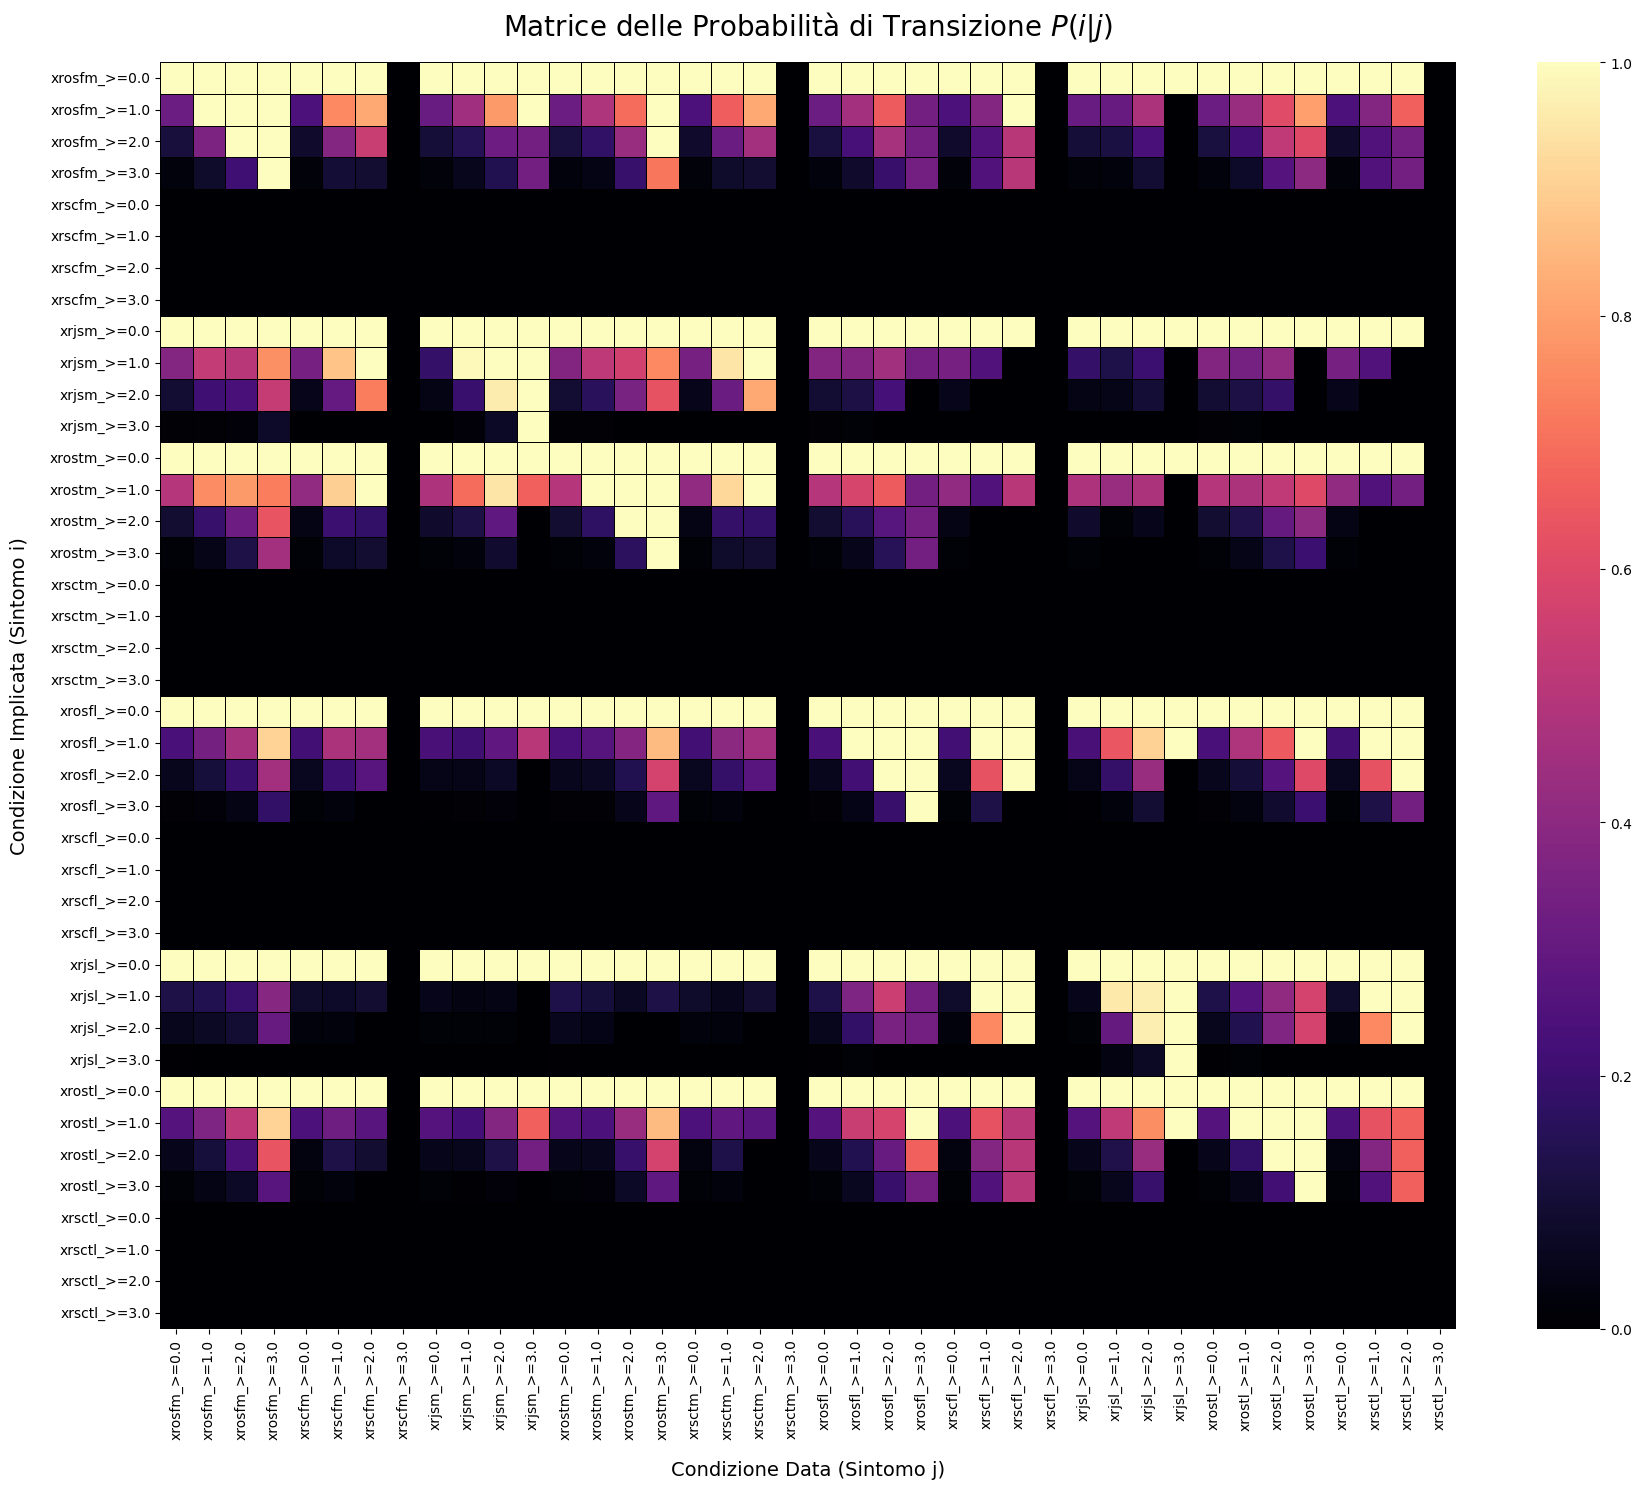

In [8]:
from src.utils.plot import plot_clinical_heatmap
labels = list(VISUAL_CONCEPTS_EXTENDED)
plot_clinical_heatmap(concept_causal_progression, concept_labels=labels)

### Train

In [ ]:
from src.CHM.model import BoxHierarchyModel
from src.CHM.train import train_box_empirical
import torch.nn as nn
from torch.optim import Adam

LR = 0.005

box_model = BoxHierarchyModel(num_concepts=concept_implications.shape[0], dim=8, soft_intersection=True)
optimizer = Adam(box_model.parameters(), lr=LR)
criterion = nn.BCELoss()

In [ ]:
box_model = train_box_empirical(
    box_model, 
    concept_implications, 
    optimizer, 
    criterion,
    epochs=100,
)

### Visualization

In [ ]:
from src.CHM.visualization import visualize_concept_hierarchy, visualize_heatmap_compare, visualize_all_boxes_2d

In [ ]:
# Dal tuo file di configurazione
CLASSES_PER_COLUMN = {
    'xrosfm': 4, 
    'xrscfm': 4,
    'xrjsm': 4, 
    'xrostm': 4, 
    'xrsctm': 4, 
    'xrosfl': 4, 
    'xrscfl': 4, 
    'xrjsl': 4,
    'xrostl': 4, 
    'xrsctl': 4,
}

# 1. Generiamo la lista espansa VISUAL_CONCEPTS
VISUAL_CONCEPTS_EXTENDED = []
for concept in VISUAL_CONCEPTS:
    # Se le classi sono 4 (0, 1, 2, 3), le soglie saranno 1.0, 2.0, 3.0
    # Escludiamo lo 0 perché rappresenta l'assenza del sintomo (nessun box)
    max_classes = CLASSES_PER_COLUMN[concept]
    
    for threshold in range(1, max_classes):
        # Aggiungiamo la stringa formattata esattamente come nella matrice Pandas
        VISUAL_CONCEPTS_EXTENDED.append(f"{concept}_>={float(threshold)}")

# 2. Creazione dei dizionari di mappatura
id2concept = {i: concept for i, concept in enumerate(VISUAL_CONCEPTS_EXTENDED)}
concept2id = {concept: i for i, concept in enumerate(VISUAL_CONCEPTS_EXTENDED)}

In [ ]:
# cambiare dim_x e dim_y (da 0 a 31) per esplorare la "forma" da diverse angolazioni
visualize_all_boxes_2d(box_model, id2concept, dim_x=0, dim_y=1)

In [ ]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "xrosfm_>=2.0", "xrosfm_>=1.0")

In [ ]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "xrjsm_>=2.0", "xrosfm_>=1.0")

In [ ]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "xrjsl_>=2.0", "xrosfl_>=1.0")

In [ ]:
visualize_concept_hierarchy(box_model, id2concept, concept2id, "xrosfm_>=2.0", "xrostm_>=1.0")

In [ ]:
from src.utils.box import extract_hierarchy
import networkx as nx
import matplotlib.pyplot as plt
from networkx.drawing.nx_pydot import pydot_layout

plt.figure(figsize=(60, 30))


hierarchy_graph = extract_hierarchy(box_model, num_concepts=len(concepts), concept_names=concepts)
pos = pydot_layout(hierarchy_graph, prog="dot")

nx.draw_networkx(
     hierarchy_graph, 
     labels=nx.get_node_attributes(hierarchy_graph, 'label'),
     node_size=1500, 
     node_color="lightblue", 
     font_size=8,
     pos=pos,
     font_weight="bold",
     edge_color="gray",
     arrows=True,
     arrowsize=15,       # Frecce ben visibili per indicare la direzione
     arrowstyle="-|>"
)
plt.title("Gerarchia dei Concetti AWA2 estratta dai Box Embeddings", fontsize=16)
plt.axis("off") # Rimuove il bordo e le coordinate dal grafico
plt.tight_layout()
plt.show()

### Save boxes

In [ ]:
from src.utils.box import get_box_dict

box_dict = get_box_dict(box_model, id2concept)

## CBM

### Load dataset

In [ ]:
import torch
torch.save(box_model.state_dict(), "modello_gerarchia.pth")

In [ ]:
box_model.load_state_dict(torch.load("modello_gerarchia.pth"))

In [ ]:
from src.utils.box import get_box_dict
box_dict = get_box_dict(box_model, id2concept)

In [ ]:
from torch.utils.data import DataLoader, TensorDataset
import numpy as np
from src.utils.box import prepara_tensore_box

box_tensors = prepara_tensore_box(box_dict, concept2id)

BOX_DIM = 32
BATCH_SIZE = 32
EPOCHS = 5
NUM_CLASSES = len(set(y_train))
NUM_CONCEPTS = len(concept2id)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

train_dataset = TensorDataset(torch.tensor(X_train).float(), torch.tensor(y_train).long())
train_dataloader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True, pin_memory=True)
val_dataset = TensorDataset(torch.tensor(X_val).float(), torch.tensor(y_val).long())
val_dataloader = DataLoader(val_dataset, batch_size=BATCH_SIZE, pin_memory=True)
test_dataset = TensorDataset(torch.tensor(X_test).float(), torch.tensor(y_test).long())
test_dataloader = DataLoader(test_dataset, batch_size=BATCH_SIZE, pin_memory=True)

In [ ]:
from src.CHM.model import ConceptBottleneckClassifier
from src.CHM.train import train_cbm_classifier
import matplotlib.pyplot as plt
from src.CHM.test import test_cbm_classifier
from src.utils.plot import plot_test_results, plot_concept_error_heatmap, analyze_misclassifications_concepts, plot_concept_uncertainty_heatmap

### CBM with boxes

#### Train

In [ ]:
b_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(b_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

info = "boxes"

b_history = train_cbm_classifier(
    b_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device
)

In [ ]:
from src.utils.plot import plot_history
plot_history(b_history)

#### Test

In [ ]:
accuracy, preds, labels, _, _, _ = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     oracle=True,
     device="cuda" if torch.cuda.is_available() else "cpu"
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(b_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, target_class="chihuahua")

### CBM with cond prob distrib

#### Train

In [ ]:
info = "rel_matrix"
bipolar = True
cp_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(cp_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
cp_history = train_cbm_classifier(
    cp_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info,
    bipolar=bipolar
)

In [ ]:
from src.utils.plot import plot_history
plot_history(cp_history)

#### Test

In [ ]:
cp_accuracy, cp_preds, cp_labels, _, _, _ = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=bipolar,
     oracle=True,
)

In [ ]:
plot_test_results(accuracy, preds, labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(
    cp_model, 
    test_dataloader, 
    concepts, 
    classes, 
    class_concept_matrix, 
    box_tensors, 
    info_type=info, 
    target_class="chihuahua", 
    bipolar=bipolar
)

### CBM standard

In [ ]:
info = "concepts"
c_model = ConceptBottleneckClassifier(box_dim=box_tensors.size(-1), num_classes=NUM_CLASSES, num_concepts=NUM_CONCEPTS, info=info)
optimizer = torch.optim.Adam(c_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()
c_history = train_cbm_classifier(
    c_model, 
    train_dataloader, 
    val_dataloader, 
    optimizer, 
    criterion, 
    class_concept_matrix, 
    box_tensors, 
    EPOCHS, 
    device,
    info=info
)

In [ ]:
from src.utils.plot import plot_history
plot_history(c_history)

In [ ]:
c_accuracy, c_preds, c_labels, _, _, _ = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     oracle=True,
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
from src.CHM.interpretation import explain_prediction

explain_prediction(c_model, test_dataloader, concepts, classes, class_concept_matrix, box_tensors, info_type=info)

## Independent

### CONCEPT PREDICTOR

In [ ]:
from src.CP.model import ConceptPredictor

concept_predictor = ConceptPredictor(X_train.shape[1], num_concepts=NUM_CONCEPTS)
optimizer = torch.optim.Adam(concept_predictor.parameters(), lr=0.001)
criterion = nn.BCEWithLogitsLoss()

In [ ]:
from src.CHM.train import train_concept_predictor

history = train_concept_predictor(
    concept_predictor, 
    train_dataloader, 
    val_dataloader, 
    class_concept_matrix, 
    optimizer, 
    criterion, 
    EPOCHS, 
    device
)

### BOXES

In [ ]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
info = "boxes"
b_accuracy, b_preds, b_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=b_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True
)

#### STATS 

In [ ]:
plot_test_results(b_accuracy, b_preds, b_labels, class_names=classes)

In [ ]:
plot_concept_error_heatmap(labels,b_concepts_preds, b_concepts_truth, classes, concepts)

In [ ]:
analyze_misclassifications_concepts(b_preds, b_labels, b_concepts_preds, b_concepts_truth, classes, concepts, num_examples=10)

In [ ]:
plot_concept_uncertainty_heatmap(labels, b_concepts_probs, class_names=classes, concept_names=concepts)

#### TEST TIME INTERVENTION

In [ ]:
from src.utils.plot import plot_intervention_curve
plot_intervention_curve(
    k_values=[0,1,2,3,4,5,10,20,25,30],
    model=b_model,
    test_loader=test_dataloader,
    class_concept_matrix=class_concept_matrix,
    boxes_tensor=box_tensors,
    device=device,
    info=info,
    concept_predictor=concept_predictor
)

### RELATION MATRIX

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

In [ ]:
info = "rel_matrix"
cp_accuracy, cp_preds, cp_labels, cp_concepts_preds, cp_concepts_truth, cp_concepts_probs = test_cbm_classifier(
     model=cp_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=True,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True,
     alpha=0.95
)

In [ ]:
plot_test_results(cp_accuracy, cp_preds, cp_labels, class_names=classes)

### STANDARD CBM

In [ ]:
info = "concepts"
c_accuracy, c_preds, c_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor
)

In [ ]:
plot_test_results(c_accuracy, c_preds, c_labels, class_names=classes)

In [ ]:
info = "concepts"
c_accuracy, c_preds, c_labels, b_concepts_preds, b_concepts_truth, b_concepts_probs = test_cbm_classifier(
     model=c_model,
     test_dataloader=test_dataloader,
     class_concept_matrix=class_concept_matrix,
     boxes_tensor=box_tensors,
     device="cuda" if torch.cuda.is_available() else "cpu",
     info=info,
     bipolar=False,
     oracle=False,
     concept_predictor=concept_predictor,
     smoothing_logic=True,
     alpha=0.95
)